# Geodesic length of centred embedding paths

What this measures, and why it is not obvious in advance.

The path database holds, for every skeleton node outside the 5 µm perisomatic
ball, **every distinct route through that node** at six budgets. Three budgets are
set in **geodesic length** (10 / 20 / 40 µm total, so L/2 per arm) and three in
**node count** (10 / 20 / 40 nodes, so k/2 per arm).

The two families are not interchangeable. A length budget is a physical distance;
a node budget is a count of embedding sites, and how much cable that spans depends
entirely on skeleton node spacing. This notebook measures the difference.

Every path is confined to one connected component of the cut skeleton, so no path
crosses between two neurites that only ever met at the soma.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

# Root of the database, holding BOTH units: paths/ and neighborhoods/.
from data.build_embedding_paths import DEFAULT_OUT as DB_ROOT
from data.soma_restrict import DEFAULT_SOMA_RADIUS_NM
RADIUS_UM = DEFAULT_SOMA_RADIUS_NM / 1000
S = np.load(REPO_ROOT / "analysis" / "embedding_paths_summary.npz", allow_pickle=False)
CONFIGS = [str(c) for c in S["configs"]]
NCONFIGS = [str(c) for c in S["nconfigs"]]
CABLE = [c for c in NCONFIGS if c.startswith("cable")]
NNODE = [c for c in NCONFIGS if c.startswith("n")]
NPAIRS = [("n10", "cable20um"), ("n20", "cable40um"), ("n40", "cable80um")]
UM = [c for c in CONFIGS if c.endswith("um")]
NODE = [c for c in CONFIGS if c.endswith("node")]

# Matched pairs. Node spacing is ~2 um, so k nodes spans about 2k um -- pairing
# 10node with 10um would compare objects differing two-fold in extent before
# anything about the model is varied. These are the like-for-like comparisons.
PAIRS = [("10node", "20um"), ("20node", "40um"), ("40node", "80um")]

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
})
COLOR = {"cable10um": "#86b6ef", "cable20um": "#2a78d6",
         "cable40um": "#1c5cab", "cable80um": "#0d366b",
         "n10": "#eb6834", "n20": "#e34948", "n40": "#4a3aa7",
         "10um": "#86b6ef", "20um": "#2a78d6", "40um": "#1c5cab", "80um": "#0d366b",
         "10node": "#eb6834", "20node": "#e34948", "40node": "#4a3aa7"}
print(f"{len(CONFIGS)} configs, summary loaded")

7 configs, summary loaded


## 1. Headline table

Percentiles are exact to the 500 nm histogram bin; node counts come from the path offsets.

In [2]:
rows = []
for c in CONFIGS:
    q = S[f"{c}__pct_q"]; nm = S[f"{c}__pct_nm"]
    p = dict(zip(q.tolist(), nm.tolist()))
    nodes = S[f"{c}__sample_nodes"]
    rows.append({
        "config": c,
        "paths": int(S[f"{c}__n_paths"][0]),
        "nodes/path p50": float(np.median(nodes)),
        "nodes/path p90": float(np.percentile(nodes, 90)),
        "geodesic p50 (µm)": p[50] / 1000,
        "geodesic p90 (µm)": p[90] / 1000,
        "geodesic p99 (µm)": p[99] / 1000,
        "mean (µm)": float(S[f"{c}__mean_nm"][0]) / 1000,
    })
tbl = pd.DataFrame(rows).set_index("config")
tbl.style.format({"paths": "{:,.0f}", "nodes/path p50": "{:.0f}", "nodes/path p90": "{:.0f}",
                  "geodesic p50 (µm)": "{:.1f}", "geodesic p90 (µm)": "{:.1f}",
                  "geodesic p99 (µm)": "{:.1f}", "mean (µm)": "{:.1f}"})

,paths,nodes/path p50,nodes/path p90,geodesic p50 (µm),geodesic p90 (µm),geodesic p99 (µm),mean (µm)
config,,,,,,,
10um,"12,860,621",5,7,8.0,9.5,10.0,7.6
20um,"14,756,314",10,13,18.0,19.5,20.0,17.1
40um,"20,990,898",20,24,37.5,39.5,40.0,35.0
80um,"44,537,647",36,46,75.5,79.0,80.0,65.9
10node,"16,393,426",11,11,19.0,27.0,39.5,20.0
20node,"24,670,264",21,21,38.0,51.0,68.5,38.6
40node,"54,212,997",38,41,72.0,93.5,119.5,70.3


## 2. Matching a node budget to a length budget

Measured node spacing is ~2 µm, so **k nodes spans roughly 2k µm**. That is why the
length budgets run 10 / 20 / 40 / **80** µm: each node budget gets a length budget
of comparable extent to sit beside.

    10 nodes  <->  20 µm
    20 nodes  <->  40 µm
    40 nodes  <->  80 µm

Pairing `10node` with `10um` instead would compare two objects differing two-fold
in physical extent before anything about the model had been varied. Below: how
closely each matched pair actually lines up.

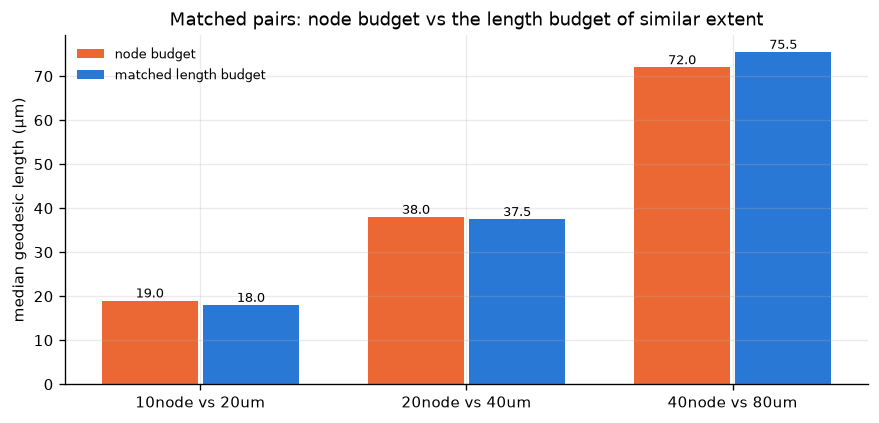

matched pairs, median geodesic length
   10node   19.0 µm   vs    20um   18.0 µm    ratio 1.06x
   20node   38.0 µm   vs    40um   37.5 µm    ratio 1.01x
   40node   72.0 µm   vs    80um   75.5 µm    ratio 0.95x

the naive (same-number) pairing, for contrast
   10node   19.0 µm   vs    10um    8.0 µm    ratio 2.38x
   20node   38.0 µm   vs    20um   18.0 µm    ratio 2.11x
   40node   72.0 µm   vs    40um   37.5 µm    ratio 1.92x


In [3]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
x = np.arange(len(PAIRS))
nd_med = [tbl.loc[n, "geodesic p50 (µm)"] for n, _ in PAIRS]
um_med = [tbl.loc[u, "geodesic p50 (µm)"] for _, u in PAIRS]
ax.bar(x - 0.19, nd_med, 0.36, label="node budget", color="#eb6834")
ax.bar(x + 0.19, um_med, 0.36, label="matched length budget", color="#2a78d6")
for xi, (n, u) in enumerate(zip(nd_med, um_med)):
    ax.text(xi - 0.19, n, f"{n:.1f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi + 0.19, u, f"{u:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"{n} vs {u}" for n, u in PAIRS])
ax.set_ylabel("median geodesic length (µm)")
ax.set_title("Matched pairs: node budget vs the length budget of similar extent")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print("matched pairs, median geodesic length")
for (n, u), a, b in zip(PAIRS, nd_med, um_med):
    print(f"  {n:>7} {a:6.1f} µm   vs   {u:>5} {b:6.1f} µm    ratio {a/b:.2f}x")
print()
print("the naive (same-number) pairing, for contrast")
for n, u in zip(NODE, ["10um", "20um", "40um"]):
    a, b = tbl.loc[n, "geodesic p50 (µm)"], tbl.loc[u, "geodesic p50 (µm)"]
    print(f"  {n:>7} {a:6.1f} µm   vs   {u:>5} {b:6.1f} µm    ratio {a/b:.2f}x")

## 3. Full distributions

**On reading the y-axis.** These are densities, so each curve integrates to 1 over
its own support — a distribution spread over a wider range is necessarily shorter.
That alone accounts for the difference in height between the two families, and it
is normalisation, not concentration:

| config | support | peak density |
|---|---|---|
| `10um` | 0–10.0 µm | 0.34 |
| `80um` | 0–80.0 µm | 0.18 |
| `10node` | 0–69.5 µm | 0.12 |
| `40node` | 0–215.6 µm | 0.031 |

The supports differ because **a length budget is hard-capped and a node budget is
not**. A `10um` arm physically cannot exceed 5 µm, so the config piles up against
its cap at exactly 10.0 µm. A `10node` path has no length cap at all — it takes 5
steps whatever they measure — so it reaches 69.5 µm where spacing is coarse. Bin
width is *not* the cause: recomputing on common 1 µm bins moves the peaks by under
8%.

So the panels below are drawn as **matched pairs on shared bins and shared axes**,
which is the only way the two families can be compared by eye.

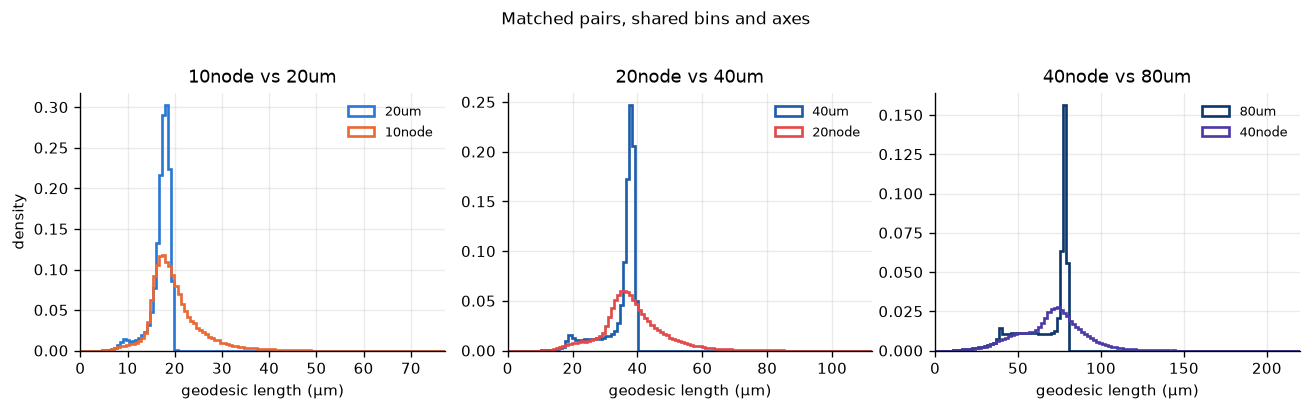

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, (nd, um) in zip(axes, PAIRS):
    hi = max(S[f"{nd}__sample_nm"].max(), S[f"{um}__sample_nm"].max()) / 1000
    edges = np.linspace(0, hi, 121)          # one shared bin set per panel
    for c in (um, nd):
        ax.hist(S[f"{c}__sample_nm"] / 1000, bins=edges, histtype="step",
                lw=1.6, density=True, color=COLOR[c], label=c)
    ax.set_xlim(0, hi); ax.set_xlabel("geodesic length (µm)")
    ax.legend(frameon=False, fontsize=8)
    ax.set_title(f"{nd} vs {um}")
axes[0].set_ylabel("density")
fig.suptitle("Matched pairs, shared bins and axes", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

The length budget stacks against its cap; the node budget leaks past
it on both sides. An ECDF makes that exact — it has no bin width and no density
normalisation, so all seven are directly comparable on one axis.

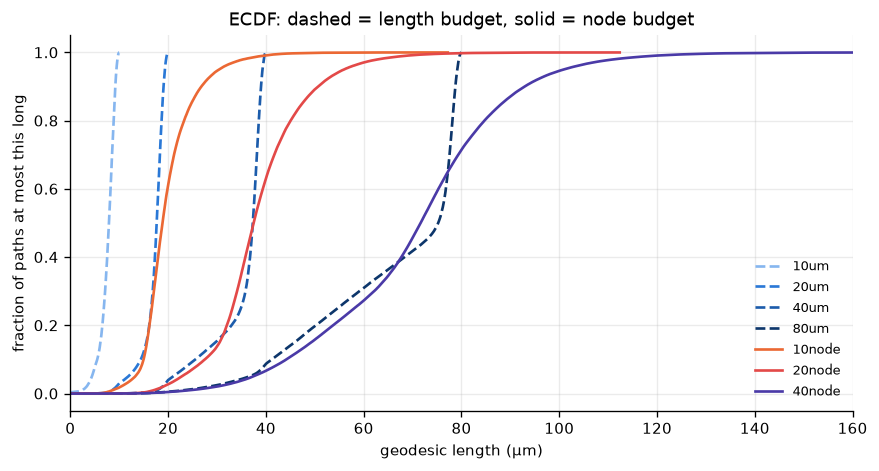

  config          support     p50     p90     p99  (µm)
    10um       0.0 - 10.0     7.9     9.2     9.7
    20um       0.0 - 20.0    17.7    19.1    19.7
    40um       0.0 - 40.0    37.3    39.0    39.7
    80um       0.0 - 80.0    75.2    78.8    79.6
  10node       0.0 - 77.2    18.9    26.8    39.2
  20node      0.0 - 112.4    37.5    50.7    68.4
  40node      0.0 - 219.7    71.6    92.9   119.0


In [5]:
fig, ax = plt.subplots(figsize=(7.4, 4))
for c in CONFIGS:
    v = np.sort(S[f"{c}__sample_nm"] / 1000)
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), lw=1.6, color=COLOR[c],
            ls="--" if c.endswith("um") else "-", label=c)
ax.set_xlim(0, 160); ax.set_xlabel("geodesic length (µm)")
ax.set_ylabel("fraction of paths at most this long")
ax.set_title("ECDF: dashed = length budget, solid = node budget")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

print(f"{'config':>8} {'support':>16} {'p50':>7} {'p90':>7} {'p99':>7}  (µm)")
for c in CONFIGS:
    v = S[f"{c}__sample_nm"] / 1000
    print(f"{c:>8} {f'{v.min():.1f} - {v.max():.1f}':>16} "
          f"{np.median(v):>7.1f} {np.percentile(v, 90):>7.1f} "
          f"{np.percentile(v, 99):>7.1f}")

## 4. Implied node spacing

If a k-node path spans D µm over its k−1 steps, the implied spacing is D/(k−1). This is the quantity that makes the two families diverge.

,nodes/path p50,spacing p50 (µm),spacing p90 (µm)
config,,,
10node,11.00,1.92,2.81
20node,21.00,2.00,2.77
40node,38.00,2.10,2.65


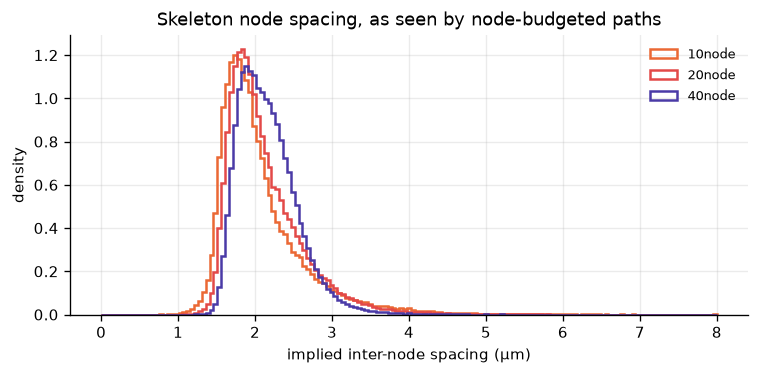

In [6]:
sp = []
for c, k in zip(NODE, (11, 21, 41)):
    v = S[f"{c}__sample_nm"] / 1000
    n = S[f"{c}__sample_nodes"].astype(float)
    ok = n > 1
    step = v[ok] / (n[ok] - 1)
    sp.append({"config": c, "nodes/path p50": float(np.median(n[ok])),
               "spacing p50 (µm)": float(np.median(step)),
               "spacing p90 (µm)": float(np.percentile(step, 90))})
sd = pd.DataFrame(sp).set_index("config")
display(sd.style.format("{:.2f}"))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
for c in NODE:
    v = S[f"{c}__sample_nm"] / 1000
    n = S[f"{c}__sample_nodes"].astype(float)
    ok = n > 1
    ax.hist(v[ok] / (n[ok] - 1), bins=np.linspace(0, 8, 160), histtype="step",
            lw=1.5, density=True, color=COLOR[c], label=c)
ax.set_xlabel("implied inter-node spacing (µm)"); ax.set_ylabel("density")
ax.set_title("Skeleton node spacing, as seen by node-budgeted paths")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 5. Per cell type

Median geodesic length per cell, grouped by type. Types whose skeletons are sampled more finely give shorter node-budgeted paths.

In [7]:
ct = {int(r): str(t) for r, t in zip(S["restrict_root_id"], S["restrict_cell_type"])}
frames = {}
for c in CONFIGS:
    rid = S[f"{c}__cell_root_id"]
    frames[c] = pd.Series(S[f"{c}__cell_median_nm"] / 1000,
                          index=[ct.get(int(r), "?") for r in rid])
by_type = pd.DataFrame({c: frames[c].groupby(level=0).median() for c in CONFIGS})
by_type["n cells"] = frames[CONFIGS[0]].groupby(level=0).size()
by_type = by_type.sort_values("40node", ascending=False)
by_type.style.format({**{c: "{:.1f}" for c in CONFIGS}, "n cells": "{:.0f}"})

,10um,20um,40um,80um,10node,20node,40node,n cells
L5ET,8.0,17.7,37.6,77.2,19.1,38.5,77.7,58
L6IT,7.9,17.7,37.6,77.4,19.1,38.2,76.9,145
L1,7.7,17.5,37.2,76.7,19.2,39.2,76.2,13
AltDTC,7.7,17.6,37.3,76.8,19.1,38.2,75.7,9
PV,7.8,17.6,37.3,76.7,18.8,37.8,75.7,174
L5IT,8.0,17.7,37.7,77.4,18.7,37.5,75.5,134
L5NP,7.9,17.7,37.6,77.3,19.0,37.9,75.3,11
L6CT,8.0,17.7,37.6,77.2,18.9,37.8,75.2,255
L2IT,7.9,17.7,37.6,77.2,18.7,37.7,75.2,346
MC,7.8,17.6,37.4,76.8,18.8,37.7,75.1,82


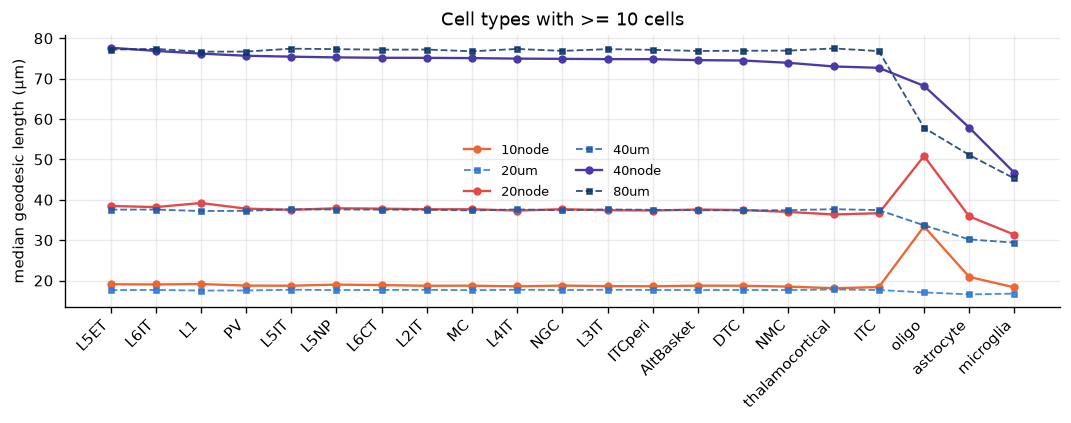

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.6))
sub = by_type[by_type["n cells"] >= 10]
xs = np.arange(len(sub))
for n, u in PAIRS:
    ax.plot(xs, sub[n], "o-", ms=4, lw=1.4, color=COLOR[n], label=n)
    ax.plot(xs, sub[u], "s--", ms=3, lw=1.1, color=COLOR[u], alpha=0.85, label=u)
ax.set_xticks(xs); ax.set_xticklabels(sub.index, rotation=45, ha="right")
ax.set_ylabel("median geodesic length (µm)")
ax.set_title("Cell types with >= 10 cells")
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 6. How many paths does a node have?

One path per node would be the answer if skeletons never branched. They do, and
every route is enumerated, so a node near a branch point carries several. Neurons
are close to unbranched at these scales; glia are not.

In [9]:
rows = []
for c in CONFIGS:
    rid = S[f"{c}__cell_root_id"]
    types = np.array([ct.get(int(r), "?") for r in rid])
    rows.append({"config": c,
                 "mean paths/node": float(np.average(S[f"{c}__cell_mean_ppn"])),
                 "max paths/node": float(S[f"{c}__cell_max_ppn"].max()),
                 "mean, neurons": float(S[f"{c}__cell_mean_ppn"][
                     ~np.isin(types, ["astrocyte", "microglia", "oligo", "OPC"])].mean()),
                 "mean, glia": float(S[f"{c}__cell_mean_ppn"][
                     np.isin(types, ["astrocyte", "microglia", "oligo", "OPC"])].mean())})
pd.DataFrame(rows).set_index("config").style.format("{:.2f}")

,mean paths/node,max paths/node,"mean, neurons","mean, glia"
config,,,,
10um,1.07,34.00,1.05,1.42
20um,1.28,192.00,1.17,3.32
40um,2.13,1315.00,1.48,13.54
80um,5.75,8343.00,2.40,64.52
10node,1.55,811.00,1.24,7.14
20node,2.86,2051.00,1.57,25.49
40node,7.71,17323.00,2.57,97.87


## 7. Reading one cell's paths, and joining embeddings

`path_nodes` indexes the **restricted** node array. `cache_index` maps that to the
row in `graph_cache/<root_id>.pt`, and `orig_node_ids` is the CAVE skeleton vertex
id — the real foreign key. Both are stored so neither has to be re-derived by
matching coordinates.

In [10]:
import torch

rid = int(S["10um__cell_root_id"][0])
P = np.load(DB_ROOT / "paths" / "10um" / f"{rid}.npz")
d = torch.load(REPO_ROOT / "data" / "graph_cache" / f"{rid}.pt", weights_only=False)

off, nodes = P["path_offsets"], P["path_nodes"]
k = int(np.argmax(np.diff(off)))                    # the longest path in this cell
p = nodes[off[k]:off[k + 1]]

emb = d.x.numpy()[P["cache_index"][p]]              # (len(path), 64) embeddings
print(f"cell {rid}: {len(off)-1:,} paths")
print(f"path {k}: {len(p)} nodes, {P['geodesic_nm'][k]:,.0f} nm, "
      f"centred on restricted node {P['center_node'][k]} at position {P['center_at'][k]}")
print(f"CAVE skeleton vertex ids: {P['orig_node_ids'][p][:6]} ...")
print(f"embedding sequence: {emb.shape}")

/home/jcbliao/rotation/segclr/gnn_classifier/segclr_db/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cell 864691134800773453: 397 paths
path 46: 9 nodes, 8,686 nm, centred on restricted node 46 at position 4
CAVE skeleton vertex ids: [59 58 60 48 46 49] ...
embedding sequence: (9, 64)


## What to take from this

- **Compare a node budget to the length budget of matching extent**, not the one
  with the same number: 10node vs 20um, 20node vs 40um, 40node vs 80um. The
  same-number pairing differs about two-fold in physical extent, which would
  confound any model comparison built on it.
- Even matched, the pairs are not identical: a node budget has a **long right
  tail** wherever spacing is coarse, while a length budget is bounded by
  construction. Matching the medians does not match the distributions.
- **Length-budgeted paths under-fill their nominal diameter** by up to one edge per
  arm, because an arm stops before overshooting. That is a property of the
  definition, not a bug.
- **Paths per node is a branching measure**, and it separates glia from neurons far
  more sharply than it separates neuron types.